In [ ]:
# @title Import Libraries & Dataset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
!pip install category_encoders -q

from google.colab import drive
drive.mount('/content/drive')

# To ignore warnings
import warnings
warnings.simplefilter(action="ignore")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.8/81.8 kB 2.0 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Model/playgolf2.csv')
df.columns

Index(['Weekday', 'Holiday', 'Temperature', 'Humidity', 'Windy', 'Outlook',
       'Crowdedness', 'PlayTime', 'Month_map', 'Humidity_cat',
       'Outlook_overcast', 'Outlook_rainy', 'Outlook_snow', 'Outlook_sunny',
       'Season_Autumn', 'Season_Spring', 'Season_Summer', 'Season_Winter',
       'Play', 'Crowdedness_bins', 'Outlook_Target', 'Month_bins',
       'Temperature_Standard', 'Humidity_Robust'],
      dtype='object')

In [ ]:
print(df)

      Weekday  Holiday  Temperature  Humidity  Windy   Outlook  Crowdedness  \
0           4        1          3.3      49.0      1     sunny         0.73   
1           5        0          2.9      53.0      0     sunny         0.74   
2           6        0          2.3      58.0      0  overcast         0.70   
3           0        0          3.0      45.0      0  overcast         0.61   
4           1        0          3.1      31.0      1     sunny         0.52   
...       ...      ...          ...       ...    ...       ...          ...   
1090        2        0          7.1      48.0      1     sunny         0.60   
1091        3        0          6.6      55.0      0  overcast         0.60   
1092        4        0          6.3      30.0      1  overcast         0.67   
1093        5        0          4.3      54.0      1  overcast         0.68   
1094        6        0          1.8      43.0      0      snow         0.57   

      PlayTime  Month_map  Humidity_cat  ...  Seaso

Accuracy of the model: 79.00%
Confusion Matrix:
 [[ 43  20]
 [ 26 130]]


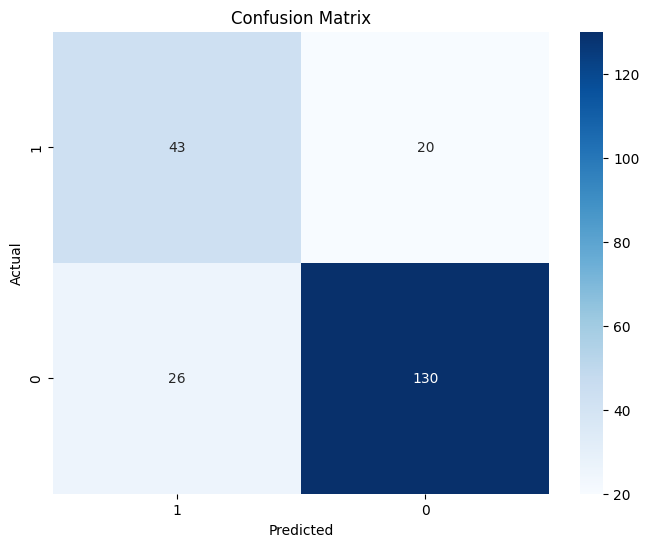

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Define your features and target variable
X = df.drop(['Play','PlayTime','Outlook'], axis=1)    # Features
y = df['Play']  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=720)

# Define hyperparameters for the Decision Tree model
hyperparameters = {
    'criterion': 'gini',  # or 'gini'
    'splitter': 'best',  # or 'random'
    'max_depth': 5,    # or a specific value
    'min_samples_split': 2,  # or a specific value
    'min_samples_leaf': 4   # or a specific value
}

# Create the Decision Tree model with specified hyperparameters
clf = DecisionTreeClassifier(criterion=hyperparameters['criterion'],
                             splitter=hyperparameters['splitter'],
                             max_depth=hyperparameters['max_depth'],
                             min_samples_split=hyperparameters['min_samples_split'],
                             min_samples_leaf=hyperparameters['min_samples_leaf'])

# Train the model on the training data
clf.fit(X_train, y_train)

# Make predictions on the test data
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the model: {accuracy * 100:.2f}%")

# Generate and display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Visualize the confusion matrix
class_names = df['Play'].unique()
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
df.columns

Index(['Weekday', 'Holiday', 'Temperature', 'Humidity', 'Windy', 'Outlook',
       'Crowdedness', 'PlayTime', 'Month_map', 'Humidity_cat',
       'Outlook_overcast', 'Outlook_rainy', 'Outlook_snow', 'Outlook_sunny',
       'Season_Autumn', 'Season_Spring', 'Season_Summer', 'Season_Winter',
       'Play', 'Crowdedness_bins', 'Outlook_Target', 'Month_bins',
       'Temperature_Standard', 'Humidity_Robust'],
      dtype='object')

In [ ]:
import pickle
from google.colab import drive
drive.mount('/content/drive')

# Define your features and target variable
X = df.drop(['Play','PlayTime','Outlook','Temperature_Standard', 'Humidity_Robust'], axis=1)    # Features
y = df['Play']  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=720)

# Define hyperparameters for the Decision Tree model
hyperparameters = {
    'criterion': 'gini',  # or 'gini'
    'splitter': 'best',  # or 'random'
    'max_depth': 5,    # or a specific value
    'min_samples_split': 2,  # or a specific value
    'min_samples_leaf': 4   # or a specific value
}

# Create the Decision Tree model with specified hyperparameters
clf = DecisionTreeClassifier(criterion=hyperparameters['criterion'],
                             splitter=hyperparameters['splitter'],
                             max_depth=hyperparameters['max_depth'],
                             min_samples_split=hyperparameters['min_samples_split'],
                             min_samples_leaf=hyperparameters['min_samples_leaf'])

# Train the model on the training data
clf.fit(X_train, y_train)

# Define the path to your Google Drive folder where you want to save the model
drive_folder_path = '/content/drive/MyDrive/Model/'

# Save the model and hyperparameters to a pickle file in Google Drive
model_path = drive_folder_path + 'decision_tree_model.pkl'
with open(model_path, 'wb') as file:
    model_to_save = {
        'model': clf,
        'hyperparameters': hyperparameters
    }
    pickle.dump(model_to_save, file)

# Make predictions on the test data
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the model: {accuracy * 100:.2f}%")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Accuracy of the model: 79.00%


In [ ]:
import pickle
from sklearn.tree import DecisionTreeClassifier

# Membuat dan melatih model Decision Tree
model = DecisionTreeClassifier()
model.fit(X_train, y_train)  # Gantilah X_train dan y_train dengan data pelatihan Anda

# Menyimpan model ke dalam file pickle
with open('/content/drive/MyDrive/Model/decision_tree_model.pkl', 'wb') as model_file:
    pickle.dump(model, model_file)


In [ ]:
from joblib import dump

# Save the trained model to Google Drive
dct = "/content/drive/MyDrive/Model/dct_golf.joblib"
dump(clf, dct)


['/content/drive/MyDrive/Model/dct_golf.joblib']

In [ ]:
# Function to calculate Outlook_Target based on Outlook
def calculate_outlook_target(outlook):
    # Define your logic here to calculate Outlook_Target based on Outlook
    # Example logic:
    if outlook == "Sunny":
        return 1
    else:
        return 0

# Function to calculate Month_bins based on Month
def calculate_month_bins(month):
    # Define your logic here to calculate Month_bins based on Month
    # Example logic:
    if month <= 3:
        return "Q1"
    elif month <= 6:
        return "Q2"
    elif month <= 9:
        return "Q3"
    else:
        return "Q4"

# Accept user input for features
weekday = int(input("Weekday (0-6, 0=Senin, 6=Minggu): "))
month = int(input("Month (1-12): "))
holiday = int(input("Holiday (0: Bukan, 1: Ya): "))
temperature = float(input("Temperature (C): "))
humidity = int(input("Humidity (%): "))
outlook = input("Outlook (Sunny/Rainy/Snow/Overcast): ")
windy = int(input("Windy (0: Tidak, 1: Ya): "))
crowdedness = float(input("Crowdedness (0-1): "))
season = input("Season (Autumn/Spring/Summer/Winter): ")

# Calculate additional features
outlook_target = calculate_outlook_target(outlook)
month_bins = calculate_month_bins(month)

# Display the calculated features
print(f"Outlook_Target: {outlook_target}")
print(f"Month_bins: {month_bins}")

# Now you can use these calculated features in your model or further processing.


Weekday (0-6, 0=Senin, 6=Minggu): 3
Month (1-12): 2
Holiday (0: Bukan, 1: Ya): 1
Temperature (C): 33
Humidity (%): 30
Outlook (Sunny/Rainy/Snow/Overcast): sunny
Windy (0: Tidak, 1: Ya): 0
Crowdedness (0-1): 0.4
Season (Autumn/Spring/Summer/Winter): autumn
Outlook_Target: 0
Month_bins: Q1


In [ ]:
df.columns

Index(['Weekday', 'Holiday', 'Temperature', 'Humidity', 'Windy', 'Outlook',
       'Crowdedness', 'PlayTime', 'Month_map', 'Humidity_cat',
       'Outlook_overcast', 'Outlook_rainy', 'Outlook_snow', 'Outlook_sunny',
       'Season_Autumn', 'Season_Spring', 'Season_Summer', 'Season_Winter',
       'Play', 'Crowdedness_bins', 'Outlook_Target', 'Month_bins',
       'Temperature_Standard', 'Humidity_Robust'],
      dtype='object')

In [ ]:
import pandas as pd
import pickle
from sklearn.preprocessing import RobustScaler, StandardScaler
from IPython.display import HTML

# Load the trained Decision Tree model from a pickle file
dct = "/content/drive/MyDrive/Model/decision_tree_model.pkl"
with open(dct, 'rb') as file:
    loaded_model = pickle.load(file)

# Accept user input for features
weekday = int(input("\nHari (0-6, 0=Senin, 6=Minggu): "))
month = int(input("\nBulan (1-12): "))
holiday = int(input("\nLibur (0: Bukan, 1: Ya): "))
temperature = float(input("\nSuhu (dalam Celcius): "))
humidity = int(input("\nKelembaban (dalam persen): "))
outlook = input("\nCuaca (Sunny/Overcast/Rainy/Snow): ").lower()
windy = int(input("\nBerangin (0: Tidak, 1: Ya): "))
crowdedness = float(input("\nCrowdedness (0-1): "))
season = input("\nMusim (Autumn/Spring/Summer/Winter): ").lower()

# Apply Robust Scaling to Humidity
robust_scaler = RobustScaler()
humidity_robust = robust_scaler.fit_transform([[humidity]])[0][0]

# Apply Standard Scaling to Temperature
std_scaler = StandardScaler()
temperature_standard = std_scaler.fit_transform([[temperature]])[0][0]

# Define a function to calculate 'Month_bins' based on 'Month'
def calculate_month_bins(month):
    if month <= 3:
        return 1
    elif month <= 6:
        return 2
    elif month <= 9:
        return 3
    else:
        return 4

# Define a function to calculate 'Outlook_Target' based on 'Outlook' and 'Crowdedness_bins'
def calculate_outlook_target(outlook, crowdedness_bins):
    if "sunny" in outlook:
        return 1 if crowdedness_bins >= 2.04 else 0
    elif "overcast" in outlook:
        return 1 if crowdedness_bins >= 1.51 else 0
    elif "rainy" in outlook:
        return 1 if crowdedness_bins >= 2.04 else 0
    elif "snow" in outlook:
        return 1 if crowdedness_bins >= 2.04 else 0
    return 0

# Define a function to calculate 'Crowdedness_bins' based on 'Crowdedness'
def calculate_crowdedness_bins(crowdedness):
    if crowdedness <= 0.25:
        return 1
    elif crowdedness <= 0.5:
        return 2
    elif crowdedness <= 0.75:
        return 3
    else:
        return 4

# Define a function to calculate 'Humidity_cat' based on 'Humidity'
def calculate_humidity_cat(humidity):
    if humidity < 45:
        return 1
    elif humidity >= 45 and humidity <= 70:
        return 2
    else:
        return 3

# Calculate 'Month_bins' and 'Crowdedness_bins'
month_bins = calculate_month_bins(month)
crowdedness_bins = calculate_crowdedness_bins(crowdedness)

# Calculate 'Outlook_Target' based on 'Outlook' and 'Crowdedness_bins'
outlook_target = calculate_outlook_target(outlook, crowdedness_bins)

# Calculate 'Humidity_cat' based on 'Humidity'
humidity_cat = calculate_humidity_cat(humidity)

# Create a DataFrame with user input
user_data = pd.DataFrame({
    'Weekday': [weekday],
    'Holiday': [holiday],
    'Temperature': [temperature],
    'Humidity': [humidity],
    'Windy': [windy],
    'Crowdedness': [crowdedness],
    'Month_map': [month],
    'Humidity_cat': [humidity_cat],  # Add Humidity_cat
    'Outlook_overcast': [1 if "overcast" in outlook else 0],
    'Outlook_rainy': [1 if "rainy" in outlook else 0],
    'Outlook_snow': [1 if "snow" in outlook else 0],
    'Outlook_sunny': [1 if "sunny" in outlook else 0],
    'Season_Autumn': [1 if season == 'autumn' else 0],
    'Season_Spring': [1 if season == 'spring' else 0],
    'Season_Summer': [1 if season == 'summer' else 0],
    'Season_Winter': [1 if season == 'winter' else 0],
    'Crowdedness_bins': [crowdedness_bins],
    'Outlook_Target': [outlook_target],
    'Month_bins': [month_bins]

    #'Temperature_Standard': [temperature_standard],  # Tambahkan 'Temperature_Standard' sesuai hasil standard scaling
    #'Humidity_Robust': [humidity_robust],
    #'Outlook': [outlook],  # Tambahkan 'Outlook' sesuai input pengguna
})

# Make a prediction using the loaded model
user_prediction = loaded_model.predict(user_data)

# Display the prediction to the user
if user_prediction[0] == 1:
    print("\nBerdasarkan input Anda, kemungkinan besar anda dapat bermain golf.")
else:
    print("\nBerdasarkan input Anda, kemungkinan besar anda tidak dapat bermain golf.")


Hari (0-6, 0=Senin, 6=Minggu): 2

Bulan (1-12): 2

Libur (0: Bukan, 1: Ya): 1

Suhu (dalam Celcius): 23

Kelembaban (dalam persen): 43

Cuaca (Sunny/Overcast/Rainy/Snow): sunny

Berangin (0: Tidak, 1: Ya): 1

Crowdedness (0-1): 0.4

Musim (Autumn/Spring/Summer/Winter): spring

Berdasarkan input Anda, kemungkinan besar anda dapat bermain golf.


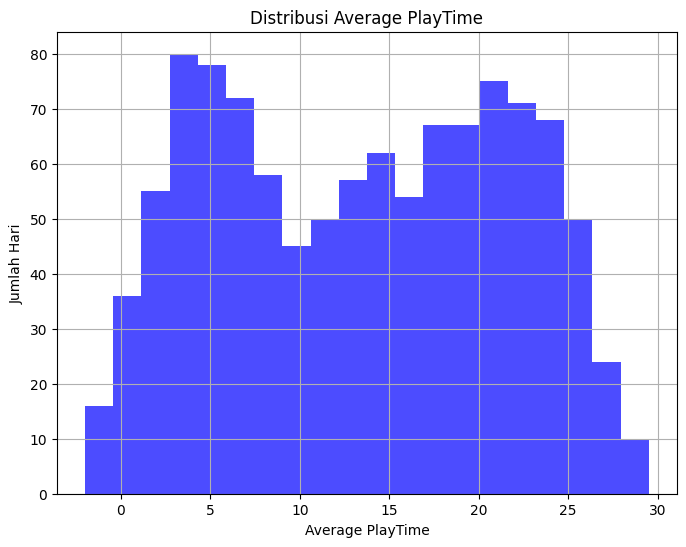

In [ ]:
# Membuat histogram distribusi Temperature
plt.figure(figsize=(8, 6))
plt.hist(df['Temperature'], bins=20, color='blue', alpha=0.7)
plt.title('Distribusi Average PlayTime')
plt.xlabel('Average PlayTime')
plt.ylabel('Jumlah Hari')
plt.grid(True)

# Menampilkan plot
plt.show()

In [ ]:
user_data


,Weekday,Holiday,Temperature,Humidity,Windy,Crowdedness,Month_map,Humidity_cat,Outlook_overcast,Outlook_rainy,...,Outlook_sunny,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Crowdedness_bins,Outlook_Target,Month_bins,Temperature_Standard,Humidity_Robust
0,0,0,3.0,45,0,0.61,1,2,1,0,...,0,0,0,0,1,3,1,1,0.0,0.0


In [ ]:
X

,Weekday,Holiday,Temperature,Humidity,Windy,Crowdedness,Month_map,Humidity_cat,Outlook_overcast,Outlook_rainy,...,Outlook_sunny,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Crowdedness_bins,Outlook_Target,Month_bins,Temperature_Standard,Humidity_Robust
0,4,1,3.3,49.0,1,0.73,1,2,0,0,...,1,0,0,0,1,3,2.04,1,-1.26,-0.60
1,5,0,2.9,53.0,0,0.74,1,2,0,0,...,1,0,0,0,1,3,2.04,1,-1.31,-0.40
2,6,0,2.3,58.0,0,0.70,1,2,1,0,...,0,0,0,0,1,2,1.51,1,-1.39,-0.15
3,0,0,3.0,45.0,0,0.61,1,1,1,0,...,0,0,0,0,1,1,1.51,1,-1.30,-0.80
4,1,0,3.1,31.0,1,0.52,1,1,0,0,...,1,0,0,0,1,0,2.04,1,-1.29,-1.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,2,0,7.1,48.0,1,0.60,12,2,0,0,...,1,0,0,0,1,1,2.04,4,-0.79,-0.65
1091,3,0,6.6,55.0,0,0.60,12,2,1,0,...,0,0,0,0,1,1,1.51,4,-0.85,-0.30
1092,4,0,6.3,30.0,1,0.67,12,1,1,0,...,0,0,0,0,1,2,1.51,4,-0.89,-1.55
1093,5,0,4.3,54.0,1,0.68,12,2,1,0,...,0,0,0,0,1,2,1.51,4,-1.14,-0.35


In [ ]:
y

0       1
1       1
2       1
3       0
4       1
       ..
1090    1
1091    0
1092    1
1093    1
1094    1
Name: Play, Length: 1095, dtype: int64

In [ ]:
df

,Weekday,Holiday,Temperature,Humidity,Windy,Outlook,Crowdedness,PlayTime,Month_map,Humidity_cat,...,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Play,Crowdedness_bins,Outlook_Target,Month_bins,Temperature_Standard,Humidity_Robust
0,4,1,3.3,49.0,1,sunny,0.73,3.37,1,2,...,0,0,0,1,1,3,2.04,1,-1.26,-0.60
1,5,0,2.9,53.0,0,sunny,0.74,3.95,1,2,...,0,0,0,1,1,3,2.04,1,-1.31,-0.40
2,6,0,2.3,58.0,0,overcast,0.70,4.60,1,2,...,0,0,0,1,1,2,1.51,1,-1.39,-0.15
3,0,0,3.0,45.0,0,overcast,0.61,0.00,1,1,...,0,0,0,1,0,1,1.51,1,-1.30,-0.80
4,1,0,3.1,31.0,1,sunny,0.52,2.80,1,1,...,0,0,0,1,1,0,2.04,1,-1.29,-1.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,2,0,7.1,48.0,1,sunny,0.60,3.20,12,2,...,0,0,0,1,1,1,2.04,4,-0.79,-0.65
1091,3,0,6.6,55.0,0,overcast,0.60,0.00,12,2,...,0,0,0,1,0,1,1.51,4,-0.85,-0.30
1092,4,0,6.3,30.0,1,overcast,0.67,3.30,12,1,...,0,0,0,1,1,2,1.51,4,-0.89,-1.55
1093,5,0,4.3,54.0,1,overcast,0.68,3.45,12,2,...,0,0,0,1,1,2,1.51,4,-1.14,-0.35


In [ ]:
df['Outlook']

0          sunny
1          sunny
2       overcast
3       overcast
4          sunny
          ...   
1090       sunny
1091    overcast
1092    overcast
1093    overcast
1094        snow
Name: Outlook, Length: 1095, dtype: object